# Phase 2: MNIST Classification – MLP vs CNN

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

## 2. Load Dataset

In [ ]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()
print("MNIST loaded:", X_train_raw.shape, y_train_raw.shape, X_test_raw.shape, y_test_raw.shape)

# Flatten for MLP
X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1).astype('float32') / 255.0
X_test_flat = X_test_raw.reshape(X_test_raw.shape[0], -1).astype('float32') / 255.0

# Normalize for CNN
X_train_cnn = X_train_raw.astype('float32') / 255.0
X_test_cnn = X_test_raw.astype('float32') / 255.0
X_train_cnn = X_train_cnn.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_cnn.reshape(-1, 28, 28, 1)

# One-hot encode labels for CNN
y_train_cat = to_categorical(y_train_raw, 10)
y_test_cat = to_categorical(y_test_raw, 10)

MNIST loaded: (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


## 3. Baseline Model – MLP

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(256,128,64),
                    activation='relu',
                    solver='adam',
                    max_iter=50,
                    random_state=42,
                    verbose=True)

mlp.fit(X_train_flat, y_train_raw)

Iteration 1, loss = 0.31503252
Iteration 2, loss = 0.11303253
Iteration 3, loss = 0.07512322
Iteration 4, loss = 0.05514518
Iteration 5, loss = 0.04157196
Iteration 6, loss = 0.03074861
Iteration 7, loss = 0.02568730
Iteration 8, loss = 0.02134472
Iteration 9, loss = 0.01624960
Iteration 10, loss = 0.01619669
Iteration 11, loss = 0.01266407
Iteration 12, loss = 0.01232077
Iteration 13, loss = 0.01063267
Iteration 14, loss = 0.01137803
Iteration 15, loss = 0.00887683
Iteration 16, loss = 0.01477981
Iteration 17, loss = 0.00923355
Iteration 18, loss = 0.00813276
Iteration 19, loss = 0.00945722
Iteration 20, loss = 0.00931820
Iteration 21, loss = 0.00552150
Iteration 22, loss = 0.00904847
Iteration 23, loss = 0.00671439
Iteration 24, loss = 0.00317221
Iteration 25, loss = 0.00956423
Iteration 26, loss = 0.01135071
Iteration 27, loss = 0.00810687
Iteration 28, loss = 0.00437323
Iteration 29, loss = 0.00247117
Iteration 30, loss = 0.00204567
Iteration 31, loss = 0.00621059
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=50, random_state=42,
              verbose=True)

MLP Accuracy: 0.9792
MLP Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.95      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.96      0.98      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



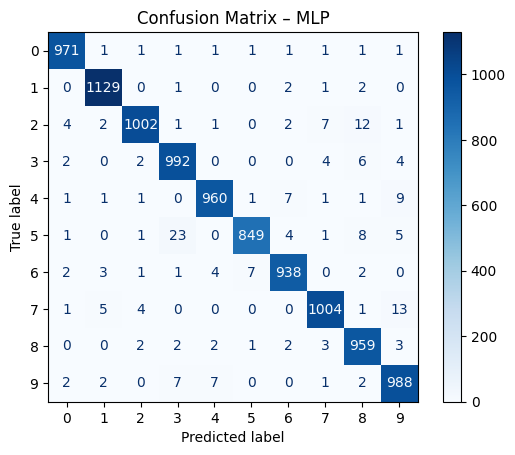

In [ ]:
y_pred_mlp = mlp.predict(X_test_flat)

print("MLP Accuracy:", accuracy_score(y_test_raw, y_pred_mlp))
print("MLP Classification Report:\n", classification_report(y_test_raw, y_pred_mlp))

cm_mlp = confusion_matrix(y_test_raw, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp).plot(cmap='Blues')
plt.title("Confusion Matrix – MLP")
plt.show()

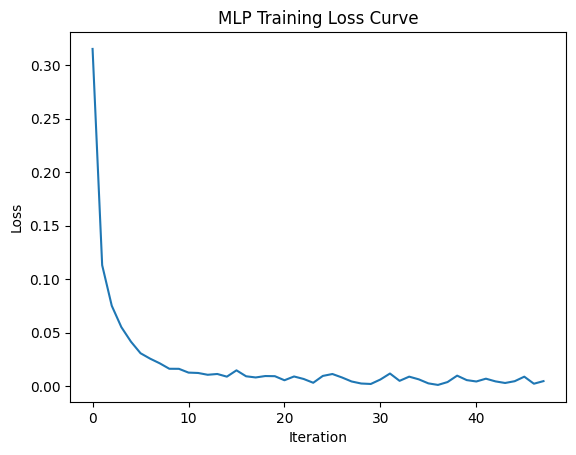

In [ ]:
# MLP Training Loss Curve
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## 4. Advanced Model – CNN

In [ ]:
cnn = Sequential([
      tf.keras.Input(shape=(28, 28, 1)),   # add this line
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = cnn.fit(X_train_cnn, y_train_cat, epochs=10, batch_size=128,
                  validation_split=0.1, verbose=2)

Epoch 1/10
422/422 - 42s - 99ms/step - accuracy: 0.8990 - loss: 0.3287 - val_accuracy: 0.9833 - val_loss: 0.0610
Epoch 2/10
422/422 - 42s - 99ms/step - accuracy: 0.9677 - loss: 0.1083 - val_accuracy: 0.9868 - val_loss: 0.0462
Epoch 3/10
422/422 - 81s - 191ms/step - accuracy: 0.9767 - loss: 0.0815 - val_accuracy: 0.9885 - val_loss: 0.0399
Epoch 4/10
422/422 - 42s - 98ms/step - accuracy: 0.9803 - loss: 0.0675 - val_accuracy: 0.9893 - val_loss: 0.0358
Epoch 5/10
422/422 - 42s - 99ms/step - accuracy: 0.9826 - loss: 0.0559 - val_accuracy: 0.9898 - val_loss: 0.0348
Epoch 6/10
422/422 - 46s - 110ms/step - accuracy: 0.9856 - loss: 0.0478 - val_accuracy: 0.9898 - val_loss: 0.0345
Epoch 7/10
422/422 - 49s - 116ms/step - accuracy: 0.9864 - loss: 0.0445 - val_accuracy: 0.9923 - val_loss: 0.0299
Epoch 8/10
422/422 - 76s - 179ms/step - accuracy: 0.9882 - loss: 0.0393 - val_accuracy: 0.9917 - val_loss: 0.0342
Epoch 9/10
422/422 - 42s - 100ms/step - accuracy: 0.9889 - loss: 0.0353 - val_accuracy: 0.99

CNN Test Accuracy: 0.9916999936103821
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
CNN Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.98      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



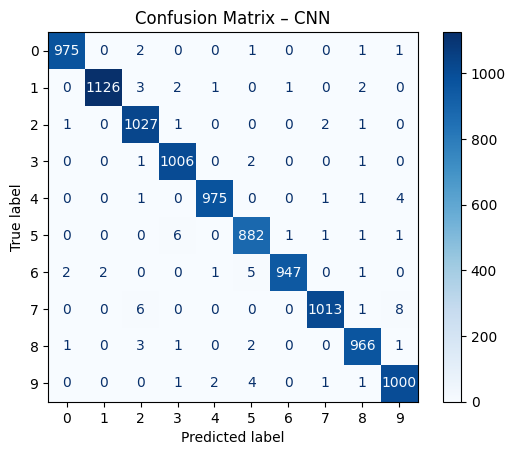

In [ ]:
test_loss, test_acc = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
print("CNN Test Accuracy:", test_acc)

y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
print("CNN Classification Report:\n", classification_report(y_test_raw, y_pred_cnn))

cm_cnn = confusion_matrix(y_test_raw, y_pred_cnn)
ConfusionMatrixDisplay(cm_cnn).plot(cmap='Blues')
plt.title("Confusion Matrix – CNN")
plt.show()

## 5. Training Curves

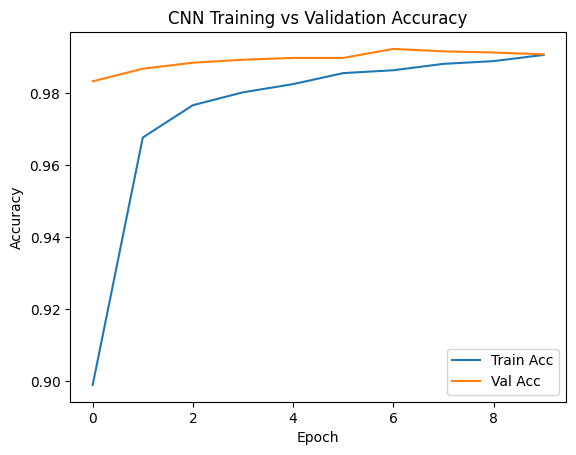

In [ ]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

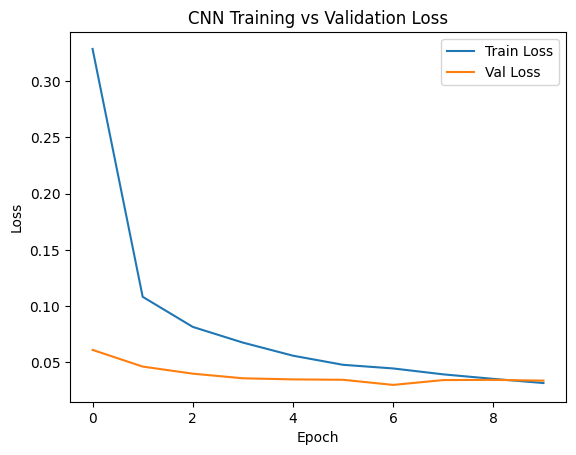

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
print("=" * 40)
print(f"MLP Test Accuracy : {accuracy_score(y_test_raw, y_pred_mlp):.4f}")
print(f"CNN Test Accuracy : {test_acc:.4f}")
print("=" * 40)
print("CNN outperforms MLP by", f"{(test_acc - accuracy_score(y_test_raw, y_pred_mlp))*100:.2f}%")

MLP Test Accuracy : 0.9792
CNN Test Accuracy : 0.9917
CNN outperforms MLP by 1.25%
